## Model Thresholding

### Setup

In [81]:
# Standard Libraries
import os
import gc
import math
import json
import datetime
from pathlib import Path
import multiprocessing

# Data Handling
import numpy as np
import pandas as pd
import nibabel as nib

# Visualization
import matplotlib.pyplot as plt
from tqdm import tqdm

# Image & Augmentation
import cv2
import albumentations as alb

# Machine Learning & PyTorch
import torch
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast
from torchvision.transforms import transforms
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split

# MONAI - Medical Imaging
from monai.networks.nets import UNETR, UNet
from monai.networks.nets import AttentionUnet as MAttentionUnet
from monai.networks.utils import one_hot
from monai.transforms import AsDiscrete
from monai.data import decollate_batch
from monai.losses import DiceLoss, DiceCELoss, HausdorffDTLoss
from monai.metrics import DiceMetric
from monai.visualize import GradCAM

# Privacy & Logging
from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
import wandb

In [2]:
seed = 42
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


### Data

In [3]:
def create_dataset_path_df(dataset_dir):
    flair_suffix = "flair.nii.gz"
    t1_suffix = "t1.nii.gz"
    t1ce_suffix = "t1ce.nii.gz"
    t2_suffix = "t2.nii.gz"
    seg_suffix = "seg.nii.gz"
    dataset_dict = {
                    'directory_path':[],
                    'flair_path':[],
                    't1_path':[],
                    't1ce_path':[],
                    't2_path':[],
                    'seg_path':[]
                    }
    missing_flair = 0
    missing_t1 = 0
    missing_t1ce = 0
    missing_t2 = 0
    missing_seg = 0
    missing_files_dirs = []
    for dir in os.listdir(dataset_dir):
        dir_path = os.path.join(dataset_dir,dir)
        if not os.path.isdir(dir_path) or not dir.startswith('BraTS2021'):
            continue
        dataset_dict['directory_path'].append(dir_path)
        
        flair_found = t1_found = t1ce_found = t2_found = seg_found = False
        for image in os.listdir(dir_path):
            image_path = os.path.join(dir_path, image)

            if image.endswith(flair_suffix):
                dataset_dict['flair_path'].append(image_path)
                flair_found = True
            elif image.endswith(t1_suffix):
                dataset_dict['t1_path'].append(image_path)
                t1_found = True
            elif image.endswith(t1ce_suffix):
                dataset_dict['t1ce_path'].append(image_path)
                t1ce_found = True
            elif image.endswith(t2_suffix):
                dataset_dict['t2_path'].append(image_path)
                t2_found = True
            elif image.endswith(seg_suffix):
                dataset_dict['seg_path'].append(image_path)
                seg_found = True

        if not flair_found:
            dataset_dict['flair_path'].append(None)
            missing_flair += 1
        if not t1_found:
            dataset_dict['t1_path'].append(None)
            missing_t1 += 1
        if not t1ce_found:
            dataset_dict['t1ce_path'].append(None)
            missing_t1ce += 1
        if not t2_found:
            dataset_dict['t2_path'].append(None)
            missing_t2 += 1
        if not seg_found:
            dataset_dict['seg_path'].append(None)
            missing_seg += 1
        if flair_found or t1_found or t1ce_found or t2_found or seg_found:
            pass
        else:
            missing_files_dirs.append(dir_path)
    print(f"Total missing files:")
    print(f"  - Flair: {missing_flair}")
    print(f"  - T1: {missing_t1}")
    print(f"  - T1ce: {missing_t1ce}")
    print(f"  - T2: {missing_t2}")
    print(f"  - Seg: {missing_seg}")
    print(f"Missing files at: {missing_files_dirs}")
    return pd.DataFrame(dataset_dict)

    return dataset_dict
dataset_dir = "../data/brats2021"
dataset = create_dataset_path_df(dataset_dir)
dataset.head()

Total missing files:
  - Flair: 0
  - T1: 0
  - T1ce: 0
  - T2: 0
  - Seg: 0
Missing files at: []


,directory_path,flair_path,t1_path,t1ce_path,t2_path,seg_path
0,../data/brats2021/BraTS2021_00000,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...
1,../data/brats2021/BraTS2021_00002,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...
2,../data/brats2021/BraTS2021_00003,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...
3,../data/brats2021/BraTS2021_00005,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...
4,../data/brats2021/BraTS2021_00006,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...


In [4]:
train_size = 0.8
val_size = 0.1
test_size = 0.1
random_state = 42
dataset_train, temp = train_test_split(dataset, test_size = val_size+test_size, random_state = random_state)
dataset_val, dataset_test = train_test_split(temp, test_size = test_size / (val_size + test_size), random_state = random_state)
print(f"Train set shape: {dataset_train.shape}")
print(f"Validation set shape: {dataset_val.shape}")
print(f"Test set shape: {dataset_test.shape}")

Train set shape: (1000, 6)
Validation set shape: (125, 6)
Test set shape: (126, 6)


### Custom Dataset Class

In [5]:
class BrainTumorDataset(Dataset):
    def __init__(self, datapath_df, upper_bound=100, lower_bound=60, window_size = 3, new_height=None, new_width=None,transformations=None):
        self._datapath_df = datapath_df
        self.upper_bound = upper_bound
        self.lower_bound = lower_bound
        self.window_size = window_size
        self.transformations = transformations

    def __len__(self):
        return self._datapath_df.shape[0]

    def _normalize_data(self, volume):
        mean = np.mean(volume)
        if mean==0:
            mean = 1
        std = np.std(volume)
        return (volume-mean)/std

    def _get_adjacent_slices(self, data, mask):
        slices = []
        masks = []
        
        depth = data.shape[-1]
        start = max(self.lower_bound, 0)
        end = min(self.upper_bound, depth)
        
        for i in range(start, end - self.window_size + 1):
            if self.window_size == 1:
                slice_group = data[:, :, :, i].transpose(1, 2, 0).astype(np.float32)
            else:
                slice_group = np.concatenate(
                    [data[:, :, :, j].transpose(1, 2, 0).astype(np.float32) for j in range(i, i + self.window_size)], 
                    axis=-1
                )
            slices.append(slice_group)
            masks.append(mask[:, :, i + self.window_size // 2].astype(np.uint8))
        
        return slices, masks

    def __getitem__(self, index):
        data = []
        row = self._datapath_df.iloc[index]
        data.append(self._normalize_data(nib.load(row.flair_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t1_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t1ce_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t2_path).get_fdata()))
        data = np.stack(data, axis=0)
        height = data.shape[1] if not new_height else new_height
        width = data.shape[2] if not new_width else new_width
        num_modalities = data.shape[0]
        num_slices = self.window_size


        mask = nib.load(row.seg_path).get_fdata()
        mask[mask == 4] = 3
        data, mask = self._get_adjacent_slices(data, mask)
        if self.transformations:
            spatial_transforms = self.transformations.get('spatial_transforms',None)
            intensity_transforms = self.transformations.get('intensity_transforms',None)

            if spatial_transforms:
                for i in range(len(data)):
                    augmented_data = spatial_transforms(image=data[i], mask=mask[i])
                    data[i], mask[i] = augmented_data["image"], augmented_data["mask"]
            if intensity_transforms:
                for i in range(len(data)):
                    augmented_data = intensity_transforms(image=data[i])
                    data[i] = augmented_data["image"]

        for i in range(len(data)):
            data[i] = data[i].reshape((height, width, num_slices, num_modalities))
            data[i] = data[i].transpose(3, 2, 0, 1)
        return data, mask

In [6]:
new_height = 240
new_width = 240
percentage_crop = 30
transformations = {}
val_transformations = {}
val_spatial_transforms = alb.Compose([
    alb.PadIfNeeded(min_height=new_height, min_width=new_width),
    alb.Resize(new_height, new_width)
], additional_targets={"mask":"mask"})

In [7]:
upper_bound=100
lower_bound=60
window_size = 1
num_modalities = 4
val_data = BrainTumorDataset(dataset_val,
                             upper_bound=upper_bound, 
                             lower_bound=lower_bound, 
                             window_size = window_size, 
                             new_height = new_height,
                             new_width = new_width,
                             transformations=val_transformations)
pd.Series({
    'Validation dataset size:': len(val_data),
}).to_frame().style.hide(axis='columns')

Validation dataset size:,125


In [8]:
def collate_fn(batch):
    data = []
    mask = []
    for X, label in batch:
        data.extend(X)
        mask.extend(label)
    data = np.array(data)
    mask = np.array(mask)
    data = torch.tensor(data, dtype=torch.float32)
    mask = torch.tensor(mask, dtype=torch.float32)
    return data, mask

per_datapoint_batch_size = (upper_bound-lower_bound)-window_size+1
batch_size_multiplication_factor = 2
batch_size = int(per_datapoint_batch_size*batch_size_multiplication_factor)
num_workers = 3
persistent_workers = True
pin_memory = True if device=='cuda' else False
pin_memory_device = device
data_loader_params = {
    'batch_size': batch_size_multiplication_factor,
    'num_workers': num_workers,
    'persistent_workers': persistent_workers,
    'pin_memory': pin_memory,
    'pin_memory_device': pin_memory_device,
    'collate_fn': collate_fn,
}
print(f'Number of datapoints per batch {batch_size}')
val_dataloader = DataLoader(val_data, **data_loader_params)

Number of datapoints per batch 80


In [9]:
pd.Series({
    'Number of batches in validation dataLoader:': len(val_dataloader),
}).to_frame().style.hide(axis='columns')

Number of batches in validation dataLoader:,63


In [10]:
for batch_idx, (data, mask) in enumerate(val_dataloader):
    print("Unique values in masks:", torch.unique(mask))
    
    print(f"Batch {batch_idx}:")
    print(f"  Data shape: {data.shape}")
    print(f"  Mask shape: {mask.shape}")
    break

Unique values in masks: tensor([0., 1., 2., 3.])
Batch 0:
  Data shape: torch.Size([80, 4, 1, 240, 240])
  Mask shape: torch.Size([80, 240, 240])


### Model

In [11]:
class UNET_V0(torch.nn.Module):
    def __init__(self,):
        super(UNET_V0, self).__init__()
        self.unet = MAttentionUnet(
                        spatial_dims=2,       # Specifies a 2D UNet (for slice-wise medical image segmentation)
                        in_channels=int(num_modalities*window_size),       # Number of input channels (e.g., multi-modal MRI with 12 input features)
                        out_channels=4,       # Number of output channels (multi-class segmentation with 4 classes)
                        channels=(16, 32, 64, 128),  # Number of feature maps at each level of the UNet
                        strides=(2, 2, 1, 1),  # Down-sampling factor at each level of the encoder (reduces spatial size)
                        kernel_size=3,        # Convolution kernel size
                        up_kernel_size=3,     # Kernel size for upsampling layers
                        dropout=0.3,          # Dropout rate for regularization (optional)
                    )

    def forward(self, X):
        X = self.unet(X)
        return X

In [12]:
model_path = '../checkpoints/BrainTumorSegmentation_V1/2025-03-27_11-46-28/UNET_V0.pth'
checkpoint = torch.load(model_path, map_location = device)
model = UNET_V0().to(device)
model.load_state_dict(checkpoint)
num_params = sum(p.numel() for p in model.parameters())
print('Number of parameters: {:.3f}K'.format(num_params / 1000))

Number of parameters: 494.456K


### Thresholding

In [26]:
model.eval()
for batch_id, (data, masks) in enumerate(val_dataloader):
    if not isDepth:
        data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)
    with torch.no_grad():
        preds = model(data)
        preds = torch.argmax(preds, dim=1)
        dice_metric(
                    y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)), 
                    y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
                    )
dice_score = dice_metric.aggregate().item()
dice_metric.reset()
np.save("BestScoreWithoutThreshold.npy", dice_score)
print(f'Base Score Without Threshold: {dice_score}')

Base Score Without Threshold: 0.7821179032325745


In [ ]:
thresholds = np.linspace(0.5,0.8, 500)
dice_scores = []
model.eval()
for threshold in thresholds:
    for batch_id, (data, masks) in enumerate(val_dataloader):
        if not isDepth:
            data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
        data = data.to(device)
        masks = masks.to(device)
        with torch.no_grad():
            preds = model(data)
            probs = torch.softmax(preds,dim=1)
            probs = torch.where(probs>=threshold,probs, torch.zeros_like(probs))
            preds = torch.argmax(probs, dim=1)
            dice_metric(
                        y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)), 
                        y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
                        )
    dice_score = dice_metric.aggregate().item()
    dice_scores.append(dice_score)
    dice_metric.reset()
np.save("CommonOptimalThreshold.npy", dice_scores)
print(f'Common Optimal Threshold: {thresholds[np.argmax(dice_scores)]}\nDice Score: {max(dice_scores)}')

In [26]:
thresholds = np.linspace(0.5,0.8, 500)

dice_scores = np.load("CommonOptimalThreshold.npy")
print(f'Common Optimal Threshold: {thresholds[np.argmax(dice_scores)]}\nDice Score: {max(dice_scores)}')

Common Optimal Threshold: 0.5054108216432865
Dice Score: 0.7816176414489746


In [31]:
thresholds = np.linspace(0.4,0.6, 50)
model.eval()
class_dice_scores = []
for class_i in range(1,num_classes):
    dice_scores = []
    for threshold in thresholds:
        for batch_id, (data, masks) in enumerate(val_dataloader):
            if not isDepth:
                data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
            data = data.to(device)
            masks = masks.to(device)
            with torch.no_grad():
                logits = model(data)
                probs = torch.softmax(logits,dim=1)
                class_probs = probs[:,class_i,:,:]
                class_probs = torch.where(class_probs>=threshold,class_probs, torch.zeros_like(class_probs))
                probs[:,class_i,:,:] = class_probs
                preds = torch.argmax(probs, dim=1)
                dice_metric(
                            y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)), 
                            y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
                            )
        dice_score = dice_metric.aggregate().item()
        dice_scores.append(dice_score)
        dice_metric.reset()
    class_dice_scores.append(dice_scores)
np.save("ClassWiseOptimalThreshold.npy", class_dice_scores)

In [32]:
class_thresholds = {}
for class_i in range(num_classes-1):
    class_dice_score = class_dice_scores[class_i]
    class_thresholds[class_i+1] = thresholds[np.argmax(class_dice_score)]
    print(f'Class-{class_i+1}\nOptimal Threshold: {class_thresholds[class_i+1]}\nDice Score: {max(class_dice_score)}\n{'-'*50}')

Class-1
Optimal Threshold: 0.4448979591836735
Dice Score: 0.7821942567825317
--------------------------------------------------
Class-2
Optimal Threshold: 0.5673469387755102
Dice Score: 0.7823365330696106
--------------------------------------------------
Class-3
Optimal Threshold: 0.40816326530612246
Dice Score: 0.7821334600448608
--------------------------------------------------


In [35]:
model.eval()
for batch_id, (data, masks) in enumerate(val_dataloader):
    if not isDepth:
        data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)
    with torch.no_grad():
        logits = model(data)
        probs = torch.softmax(logits,dim=1)
        for class_i in range(1,num_classes):
            class_probs = probs[:,class_i,:,:]
            class_probs = torch.where(class_probs>=class_thresholds[class_i], class_probs, torch.zeros_like(class_probs))
            probs[:,class_i,:,:] = class_probs
        preds = torch.argmax(probs, dim=1)
        dice_metric(
                    y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)), 
                    y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
                    )
dice_score = dice_metric.aggregate().item()
dice_metric.reset()
np.save("FinalDice.npy", dice_score)
print(f'Final Score With Threshold Optimization: {dice_score}')

Final Score With Threshold Optimization: 0.7821524739265442


(-0.5, 239.5, 239.5, -0.5)

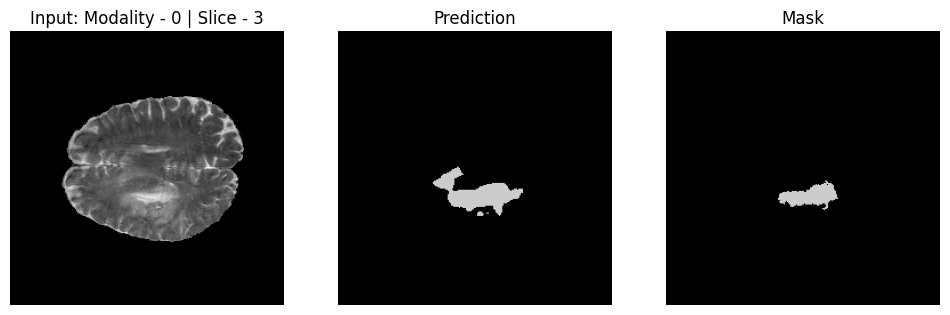

In [36]:
data, masks = next(iter(val_dataloader))
if not isDepth:
    data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
model.eval()
with torch.no_grad():
    logits = model(data.to(device))
probs = torch.softmax(logits,dim=1)
for class_i in range(1,num_classes):
    class_probs = probs[:,class_i,:,:]
    class_probs = torch.where(class_probs>=class_thresholds[class_i], class_probs, torch.zeros_like(class_probs))
    probs[:,class_i,:,:] = class_probs
preds = torch.argmax(probs, dim=1)
idx = np.random.randint(preds.shape[0])

modality = 0 # 0-2, 3-5, 6-8, 9-11
slice_num = 3
scan = data[idx,slice_num,...].cpu().numpy()
pred = preds[idx].cpu().numpy()
mask = masks[idx].cpu().numpy()

plt.figure(figsize=(12,12))
plt.subplot(1,3,1)
plt.imshow(scan, cmap="grey")
plt.title(f"Input: Modality - {modality} | Slice - {slice_num}")
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(pred, cmap="nipy_spectral")
plt.title("Prediction")
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(mask, cmap="nipy_spectral")
plt.title("Mask")
plt.axis('off')